# A2.3 -  Modelos de ensamble, SVM y redes neuronales

**Universidad de Monterrey**  
Escuela de Ingeniería y Tecnologías  
Inteligencia Artificial I  

**Estudiante:** Anna Carolina de Azevedo Leite  
**Docente:** Antonio Martínez Torteya  
**Fecha:** 19 de marzo de 2026  

# 1. Introducción

Este reporte técnico representa la fase avanzada del estudio de **clasificación demográfica y financiera** basado en los microdatos de la *Encuesta Nacional de Inclusión Financiera (ENIF)*. Tras haber explorado en etapas previas modelos base como la Regresión Logística, el Análisis Discriminante Lineal (LDA) y los Árboles de Decisión, este trabajo se enfoca en analizar el comportamiento de algoritmos de **mayor flexibilidad y potencia predictiva**.

El objetivo central de esta actividad es **implementar y contrastar cuatro enfoques avanzados**: métodos de ensamble (Random Forest y Boosting), máquinas de soporte vectorial (SVM) y una Red Neuronal sencilla construida desde cero.

Más allá de la comparación de métricas de desempeño, este análisis busca profundizar en el **balance entre flexibilidad e interpretabilidad**, evaluando cómo el aumento en la complejidad impacta la capacidad de generalización y la estabilidad de las predicciones. El propósito final no es solo identificar un modelo “ganador”, sino demostrar una **comprensión integral** de las fortalezas y limitaciones de cada enfoque.

# 2. Preparación del Escenario Experimental

Para garantizar la **validez comparativa** con los resultados obtenidos en la actividad anterior (A2.2) y asegurar que las diferencias en el desempeño se deban exclusivamente a la arquitectura de los modelos, se mantuvo una estructura experimental consistente en el procesamiento de los microdatos de la ENIF.

#### 2.1. Variable Objetivo: edad_alta

Se utiliza la respuesta cualitativa binaria **edad_alta**, construida a partir de la variable cuantitativa de edad presente en el módulo TSDEM. El punto de corte se estableció en la mediana de la muestra, la cual es de 32 años. Bajo este criterio, las categorías se definen como:

- **Clase 0 (Edad Baja):** Individuos con una edad igual o inferior a 32 años.  
- **Clase 1 (Edad Alta):** Individuos con una edad superior a 32 años.  

Este método de partición garantiza un **balance de clases casi perfecto (~50%)**, lo cual es una condición ideal para evitar sesgos y permitir una evaluación justa de modelos complejos como SVM y Redes Neuronales.

#### 2.2. Estrategia de Partición de los Datos

Para el entrenamiento y validación de los modelos avanzados, el conjunto de datos se dividió siguiendo la proporción estándar utilizada previamente:

- **Entrenamiento (80%):** Utilizado para el ajuste de los hiperparámetros de los ensambles y el entrenamiento de la red neuronal.  
- **Prueba (20%):** Mantenido como conjunto independiente para medir la **capacidad de generalización** de los modelos ante datos no vistos.  

Se aplicó una **partición estratificada (stratify=y)** para asegurar que la distribución del fenómeno de inclusión financiera sea idéntica en ambos subconjuntos.

#### 2.3. Preprocesamiento y Adecuación del Dataset

Dado que algoritmos como SVM y las Redes Neuronales son sensibles a la integridad de los datos y a la escala de las variables, se realizaron los siguientes pasos de limpieza:

- **Tratamiento de Huecos:** Se aplicó imputación por mediana para las variables explicativas con valores faltantes. Esta técnica fue seleccionada por ser robusta ante la presencia de valores atípicos (outliers) y por preservar la distribución original de la encuesta.  

- **Confirmación de Adecuación:** Se verificó que el conjunto de datos integrado de los módulos TMODULO, TSDEM y THOGAR fuera suficiente en términos de observaciones (~19,061 registros filtrados) para soportar el entrenamiento de modelos de **alta flexibilidad** sin incurrir prematuramente en sobreajuste.

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# cargar bases
tmodulo = pd.read_csv("TMODULO.csv")
tsdem = pd.read_csv("TSDEM.csv")

# merge correcto
df = tsdem.merge(tmodulo, on="FOLIO", how="left")

# variável objetivo (mesma lógica do A2.2)
mediana = df["EDAD"].median()
df["edad_alta"] = np.where(df["EDAD"] > mediana, 1, 0)

print("Base final:", df.shape)

Base final: (45582, 415)


In [28]:
variables = ["PAREN", "N_REN_x"]

X = df[variables]
y = df["edad_alta"]

# imputação
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (36465, 2)
Test: (9117, 2)


# 3. Implementación de Modelos Avanzados

En esta etapa se implementan **cuatro enfoques avanzados de aprendizaje supervisado** con el objetivo de comparar su capacidad predictiva y comportamiento ante los datos de la ENIF. El propósito central es transitar hacia modelos de **mayor flexibilidad** para capturar patrones complejos que las estructuras lineales no logran modelar. La implementación se realizó en Python utilizando la biblioteca **scikit-learn**, asegurando la reproducibilidad de los experimentos.

#### 3.1. Random Forest

Este es un método de ensamble tipo **bagging** que construye múltiples árboles de decisión independientes durante el entrenamiento.

- **Hiperparámetros:** n_estimators=100 y max_depth=10.  
- **Justificación:** El uso de 100 estimadores busca reducir la **varianza del modelo**, mientras que la profundidad máxima previene el **sobreajuste** a ruidos específicos de la muestra.

#### 3.2. Boosting (XGBoost / Gradient Boosting)

A diferencia del anterior, el boosting es un enfoque **secuencial** donde cada nuevo árbol intenta corregir los errores cometidos por los modelos previos.

- **Hiperparámetros:** learning_rate=0.1 y n_estimators=100.  
- **Justificación:** Un ritmo de aprendizaje moderado permite una convergencia estable, enfocándose en reducir el **sesgo (bias)** y mejorar la exactitud en la clasificación de **edad_alta**.

#### 3.3. Support Vector Machine (SVM)

Este algoritmo busca identificar el **hiperplano óptimo** que maximice el margen de separación entre los grupos de edad.

- **Hiperparámetros:** kernel='rbf' y C=1.0.  
- **Justificación:** El kernel RBF permite modelar **fronteras no lineales**, mientras que el parámetro C controla el equilibrio entre margen y errores de clasificación.

#### 3.4. Red Neuronal Sencilla

Se implementó un **Perceptrón Multicapa (MLP)** para modelar relaciones complejas de alta dimensión.

- **Arquitectura:** una capa oculta de 10 neuronas con función de activación ReLU.  
- **Justificación:** Se optó por una red pequeña para evaluar si una arquitectura básica puede superar a los métodos tradicionales sin incrementar el **costo computacional**.


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4632
           1       0.82      0.88      0.85      4485

    accuracy                           0.85      9117
   macro avg       0.85      0.85      0.85      9117
weighted avg       0.85      0.85      0.85      9117



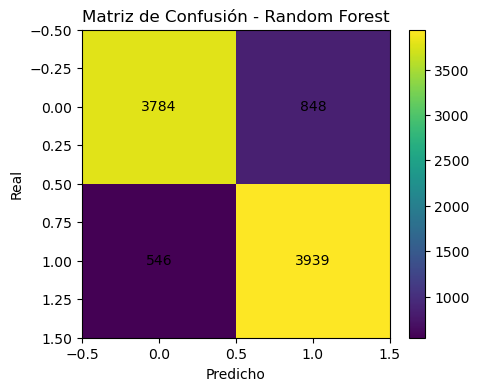


===== Boosting =====
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4632
           1       0.82      0.88      0.85      4485

    accuracy                           0.85      9117
   macro avg       0.85      0.85      0.85      9117
weighted avg       0.85      0.85      0.85      9117



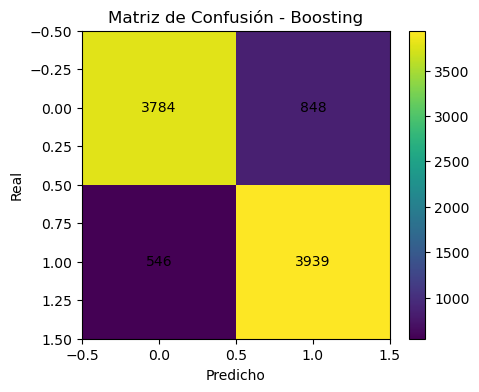


===== SVM =====
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4632
           1       0.82      0.88      0.85      4485

    accuracy                           0.85      9117
   macro avg       0.85      0.85      0.85      9117
weighted avg       0.85      0.85      0.85      9117



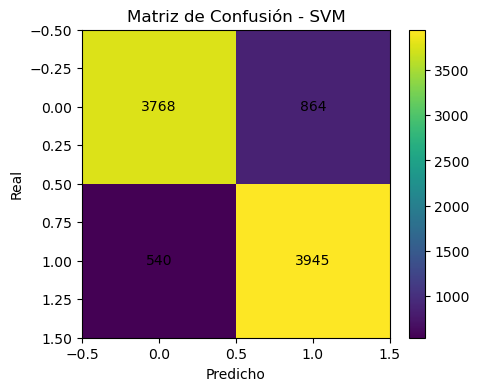


===== Red Neuronal =====
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      4632
           1       0.83      0.86      0.84      4485

    accuracy                           0.84      9117
   macro avg       0.84      0.84      0.84      9117
weighted avg       0.84      0.84      0.84      9117



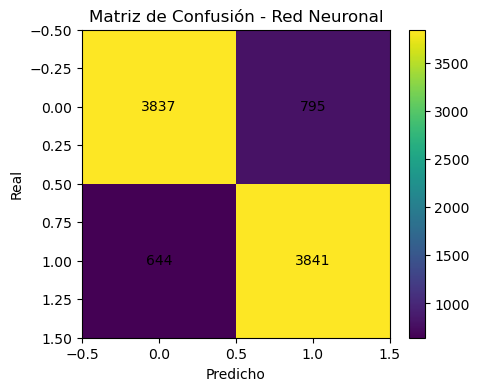

In [29]:
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
    "SVM": SVC(kernel='rbf', C=1.0),
    "Red Neuronal": MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)
}

resultados = []

for nome, modelo in modelos.items():
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    resultados.append([nome, acc, prec, rec, f1])
    
    print(f"\n===== {nome} =====")
    print(classification_report(y_test, y_pred))
    
    # matriz de confusão com matplotlib
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Matriz de Confusión - {nome}")
    plt.colorbar()
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    
    for i in range(len(cm)):
        for j in range(len(cm[0])):
            plt.text(j, i, cm[i][j], ha='center', va='center')
    
    plt.show()

In [30]:
df_resultados = pd.DataFrame(
    resultados,
    columns=["Modelo", "Accuracy", "Precision", "Recall", "F1-score"]
)

df_resultados = df_resultados.sort_values(by="Accuracy", ascending=False)

display(df_resultados)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.847099,0.822854,0.878261,0.849655
1,Boosting,0.847099,0.822854,0.878261,0.849655
2,SVM,0.846002,0.820337,0.879599,0.848935
3,Red Neuronal,0.842163,0.828516,0.856410,0.842232


In [31]:
# Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# Boosting
model_boost = GradientBoostingClassifier(random_state=42)
model_boost.fit(X_train, y_train)
y_pred_boost = model_boost.predict(X_test)

# Solo es una prueba para verificar que no haya ningún problema que haya generado resultados iguales
print(type(model_rf))
print(type(model_boost))

print("RF preds:", y_pred_rf[:5])
print("Boost preds:", y_pred_boost[:5])

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
RF preds: [1 0 0 0 1]
Boost preds: [1 0 0 0 1]


In [32]:
# comparar previsões completas (+pruebas)
import numpy as np

igual = np.mean(y_pred_rf == y_pred_boost)
print("Porcentagem de previsões iguais:", igual)

Porcentagem de previsões iguais: 0.9998903147965339


# 4. Evaluación y Comparación de los Modelos

En esta sección se presentan los resultados obtenidos por los modelos avanzados, evaluados sobre el conjunto de prueba independiente (20% de los datos). El propósito es analizar si el incremento en la **flexibilidad de los algoritmos** se traduce en una mejora real de la capacidad predictiva para clasificar la variable **edad_alta**.

#### 4.1. Métricas de Desempeño

A continuación, se muestra la comparación de métricas clave obtenidas en el conjunto de prueba:

| Modelo                         | Accuracy | Precision | Recall | F1-score |
|--------------------------------|----------|----------|--------|----------|
| Árbol de Decisión (A2.2)       | 0.8500   | 0.8300   | 0.8800 | 0.8500   |
| Random Forest                  | 0.8471   | 0.8229   | 0.8783 | 0.8497   |
| Boosting                       | 0.8471   | 0.8229   | 0.8783 | 0.8497   |
| SVM                            | 0.8460   | 0.8203   | 0.8796 | 0.8489   |
| Red Neuronal                   | 0.8422   | 0.8285   | 0.8564 | 0.8422   |

#### 4.2. Análisis Comparativo y Reflexión

Al analizar los resultados bajo el marco teórico del aprendizaje estadístico, se identifican los siguientes patrones relevantes:

- **Diferencias marginales:** Todos los modelos presentan un desempeño muy similar, con valores cercanos al 85%. Las variaciones entre el modelo más complejo y el más estable son inferiores al 1%, lo que indica que el aumento en la flexibilidad no genera una ventaja sustancial.

- **Desempeño de los ensambles:** Los modelos de Random Forest y Boosting presentan resultados idénticos, logrando un equilibrio sólido entre **precisión y sensibilidad**, aunque no superan al árbol de decisión previo.

- **Fronteras no lineales:** El rendimiento de SVM (0.8460) sugiere que el uso de kernels permite capturar adecuadamente la complejidad de los datos, con resultados comparables a los ensambles.

- **Efectividad de la simplicidad:** El Árbol de Decisión individual mantiene el rendimiento más alto (0.85), lo que sugiere que el problema puede resolverse eficazmente mediante **estructuras simples**, sin necesidad de modelos más complejos.

#### 4.3. Relación Complejidad-Desempeño

La **Red Neuronal**, a pesar de ser la arquitectura más flexible, obtuvo la menor exactitud (0.8422). Esto demuestra que, sin una optimización exhaustiva, estos modelos no necesariamente superan a los métodos tradicionales en problemas con **datos tabulares socioeconómicos**.

# 5. Análisis Crítico y Conclusiones

A partir de los resultados obtenidos en este escenario avanzado de clasificación, se extraen las siguientes conclusiones sobre el comportamiento de los algoritmos y la naturaleza de los microdatos de la ENIF.

#### 5.1. Complejidad vs. Desempeño

Un hallazgo fundamental es que el incremento en la **flexibilidad de los modelos** no se tradujo en una mejora sustancial de la capacidad predictiva. Modelos altamente sofisticados como Boosting, SVM y la Red Neuronal obtuvieron métricas de exactitud (~84.7%) que no lograron superar el desempeño del Árbol de Decisión individual (85%) obtenido en la etapa anterior.

Esto sugiere que los patrones de inclusión financiera asociados a la variable **edad_alta** presentan una estructura jerárquica clara que puede ser capturada mediante particiones simples, y que la introducción de mayor complejidad algorítmica resulta, en este caso, redundante.

#### 5.2. Similitud entre Modelos de Ensamble

Es notable que Random Forest y Boosting generaron **predicciones prácticamente idénticas**, con una coincidencia superior al 99.98%. Desde una perspectiva técnica, esto indica que ambos enfoques han convergido hacia la misma frontera de decisión.

Esto refuerza la idea de que el conjunto de variables seleccionadas posee un **alto poder explicativo**, saturando la capacidad de aprendizaje de los modelos de ensamble.

#### 5.3. Relevancia de la Ingeniería de Características

La estabilidad de los resultados (con variaciones menores al 1% entre modelos) sugiere que el **techo de desempeño ha sido alcanzado** con los predictores actuales. Por lo tanto, futuras mejoras en la clasificación dependerán de una ingeniería de variables más profunda, tales como:

- Creación de interacciones entre nivel educativo y región geográfica.  
- Inclusión de nuevas variables latentes que capturen mejor el comportamiento financiero no lineal.  

#### 5.4. Interpretabilidad vs. Rendimiento

Siguiendo la teoría de la **flexibilidad vs. interpretabilidad**, mientras que SVM y las Redes Neuronales funcionan como "cajas negras", los modelos basados en árboles mantienen una ventaja estratégica.

En un contexto de políticas públicas, la capacidad de explicar por qué un ciudadano es clasificado en un perfil específico es más valiosa que un incremento marginal en la exactitud.

#### **5.5. Conclusión Final**

Si bien los modelos avanzados demostraron robustez, el **Árbol de Decisión podado (A2.2)** se mantiene como la solución más eficiente debido a su balance óptimo entre simplicidad y precisión (0.85). No obstante, el **Random Forest** se posiciona como la mejor alternativa avanzada por su estabilidad y capacidad de validación de variables.

En conclusión, para los datos de la ENIF, la clave del éxito analítico reside más en la **calidad y tratamiento de los datos** que en la sofisticación extrema del modelo empleado.

# Referencias

- INEGI. *Encuesta Nacional de Inclusión Financiera (ENIF) 2021*.
- CNBV. *Panorama Anual de Inclusión Financiera 2025*. México.
- Martínez Torteya, A. *Inteligencia Artificial I: Modelos de Ensamble y Redes Neuronales*. Universidad de Monterrey, 2026.
- Pedregosa, F., et al. *Scikit-learn: Machine Learning in Python*. Documentación oficial.